# SaaS / E-Commerce Cohort Retention & CLTV Analysis

## Data Analytics Internship Project

### Project Overview

Customer retention is one of the most important performance indicators for subscription-based businesses and e-commerce platforms. This project analyzes customer purchasing behavior using Cohort Analysis and Customer Lifetime Value (CLTV) techniques to identify retention trends and support data-driven business decisions.

---

### Objectives

- Clean and preprocess transactional data.
- Perform Exploratory Data Analysis (EDA).
- Build customer cohorts based on acquisition month.
- Measure monthly customer retention.
- Calculate Customer Lifetime Value (CLTV).
- Generate actionable business insights.
- Develop an interactive Power BI dashboard.

---

### Dataset

Online Retail II Dataset

Period:
December 2009 – December 2011

Source:
Online Retail II (UCI / Kaggle)

In [1]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_5cf9739858c069c4f3f513ed8f6e8884"

In [2]:
!pip install -q kaggle


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!kaggle datasets download -d mashlyn/online-retail-ii-uci

Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
online-retail-ii-uci.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
!unzip -q online-retail-ii-uci.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [14]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  float64
 7   Country      779425 non-null  str    
 8   Revenue      779425 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 53.5 MB


In [16]:
df.shape

(779425, 9)

In [17]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [18]:
df.dtypes

Invoice                 int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
Revenue               float64
dtype: object

# SaaS / E-Commerce Cohort Retention & CLTV Analysis

## Objective
This project analyzes customer retention using cohort analysis and estimates Customer Lifetime Value (CLTV). The goal is to identify customer churn patterns and provide actionable business recommendations to improve customer retention.

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [22]:
df = pd.read_csv("../data/raw/online_retail_II.csv")

In [23]:
df.shape

(1067371, 8)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [25]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(34335)

In [27]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [28]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [29]:
df = df.dropna(subset=["Customer ID"])

In [30]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [31]:
df = df[df["Quantity"] > 0]

In [32]:
df = df[df["Price"] > 0]

In [33]:
df = df.drop_duplicates()

In [34]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [35]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

In [36]:
cohort = (
    df.groupby("Customer ID")["InvoiceMonth"]
      .min()
)

df["CohortMonth"] = df["Customer ID"].map(cohort)

In [37]:
invoice_year = df["InvoiceMonth"].dt.year
invoice_month = df["InvoiceMonth"].dt.month

cohort_year = df["CohortMonth"].dt.year
cohort_month = df["CohortMonth"].dt.month

df["CohortIndex"] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
    + 1
)

In [38]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,InvoiceMonth,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,2009-12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2009-12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2009-12,1


In [39]:
df.to_csv("cleaned_online_retail.csv", index=False)

# Week 2: Cohort Retention Analysis

## Objective

The goal of this section is to analyze customer retention over time using cohort analysis. Customers are grouped based on the month of their first purchase (Cohort Month). By tracking how many customers return in subsequent months, we can identify retention trends, churn patterns, and opportunities to improve customer loyalty.

## 1. Calculate Cohort Sizes

Count the number of unique customers for each cohort and each month after acquisition.

In [40]:
cohort_data = (
    df.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
      .nunique()
      .reset_index(name="Customers")
)

cohort_data.head()

,CohortMonth,CohortIndex,Customers
0,2009-12,1,955
1,2009-12,2,337
2,2009-12,3,319
3,2009-12,4,406
4,2009-12,5,363


## 2. Build the Cohort Matrix

Transform the grouped data into a matrix where:

- Rows represent acquisition cohorts.
- Columns represent months since acquisition.
- Values represent the number of retained customers.

In [41]:
cohort_matrix = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customers"
)

cohort_matrix

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,359.0,270.0,233.0,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,66.0,85.0,68.0,72.0,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,43.0,47.0,57.0,65.0,46.0,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,51.0,63.0,89.0,72.0,89.0,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,22.0,41.0,41.0,46.0,46.0,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,29.0,34.0,39.0,39.0,25.0,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,29.0,37.0,40.0,33.0,30.0,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,25.0,27.0,25.0,25.0,36.0,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,21.0,20.0,25.0,30.0,29.0,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Calculate Monthly Retention Rates

Retention rate is calculated by dividing the number of returning customers in each month by the number of customers in the first month of the cohort.

In [42]:
retention_matrix = cohort_matrix.divide(
    cohort_matrix.iloc[:, 0],
    axis=0
)

retention_matrix.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.352880,0.334031,0.425131,0.380105,0.359162,0.376963,0.342408,0.336126,0.362304,0.421990,0.495288,0.375916,0.282723,0.243979,0.302618,0.262827,0.302618,0.282723,0.259686,0.255497,0.315183,0.304712,0.407330,0.196859
2010-01,1.0,0.206266,0.310705,0.305483,0.263708,0.300261,0.258486,0.229765,0.279373,0.318538,0.302872,0.172324,0.221932,0.177546,0.187990,0.151436,0.234987,0.198433,0.185379,0.195822,0.242820,0.193211,0.245431,0.057441,NaN
2010-02,1.0,0.237968,0.224599,0.291444,0.245989,0.200535,0.192513,0.286096,0.254011,0.275401,0.114973,0.125668,0.152406,0.173797,0.122995,0.200535,0.160428,0.163102,0.144385,0.229947,0.229947,0.163102,0.058824,NaN,NaN
2010-03,1.0,0.189616,0.230248,0.241535,0.232506,0.203160,0.246050,0.302483,0.275395,0.108352,0.115124,0.142212,0.200903,0.162528,0.200903,0.169300,0.173815,0.155756,0.176072,0.200903,0.212190,0.079007,NaN,NaN,NaN
2010-04,1.0,0.193878,0.193878,0.163265,0.183673,0.224490,0.275510,0.261905,0.105442,0.108844,0.074830,0.139456,0.139456,0.156463,0.156463,0.156463,0.139456,0.149660,0.180272,0.224490,0.057823,NaN,NaN,NaN,NaN


In [43]:
retention_percentage = retention_matrix * 100
retention_percentage = retention_percentage.round(2)

retention_percentage

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,37.59,28.27,24.40,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,17.23,22.19,17.75,18.80,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,11.50,12.57,15.24,17.38,12.30,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,11.51,14.22,20.09,16.25,20.09,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,7.48,13.95,13.95,15.65,15.65,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,12.60,5.91,8.27,11.42,13.39,15.35,15.35,9.84,12.60,13.78,16.54,15.35,4.72,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,12.59,8.89,8.15,11.85,10.74,13.70,14.81,12.22,11.11,12.22,13.33,20.37,5.19,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,13.98,11.29,14.52,14.52,11.29,13.44,14.52,13.44,13.44,19.35,17.20,23.66,8.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,17.28,11.73,9.88,12.35,13.58,12.96,12.96,12.35,15.43,18.52,17.90,19.75,6.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Cohort Retention Heatmap

The heatmap visualizes customer retention across different cohorts. Darker colors indicate stronger retention, while lighter colors indicate higher churn.

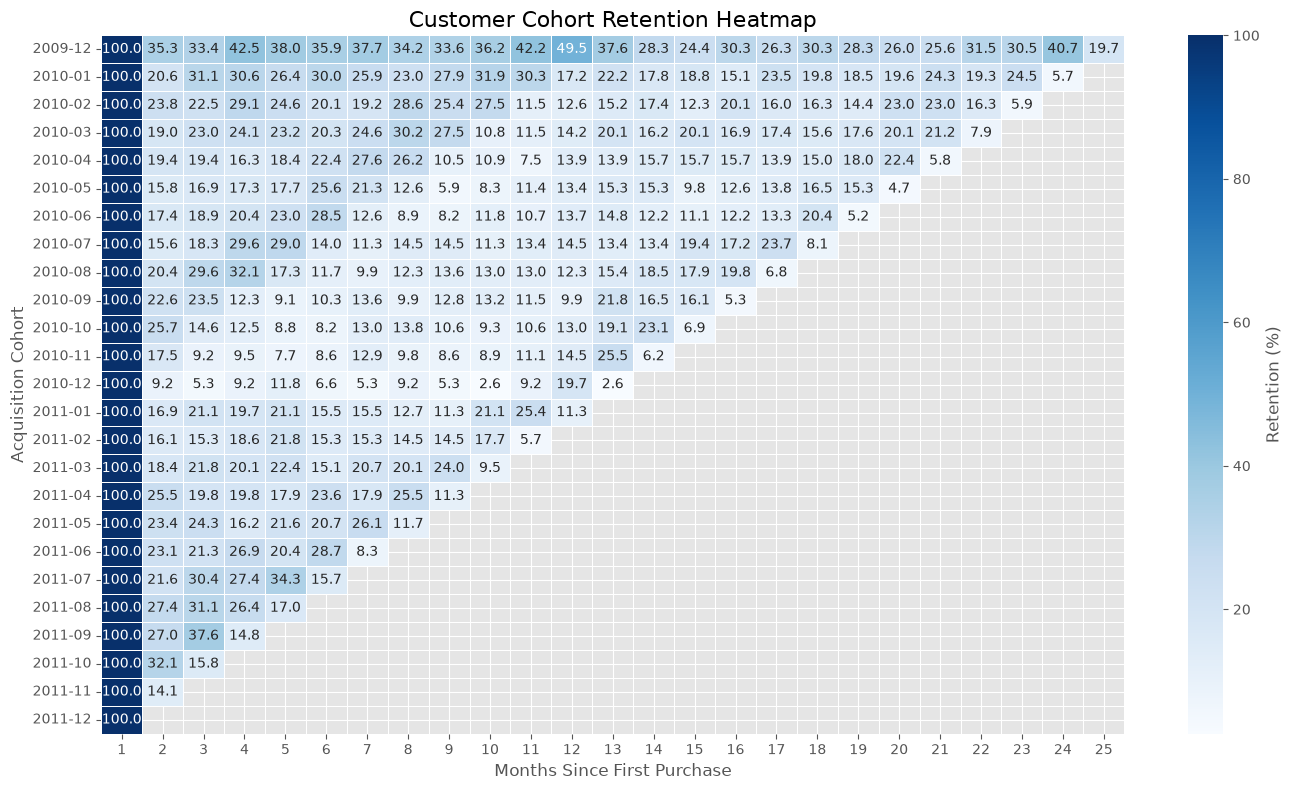

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Retention (%)"}
)

plt.title("Customer Cohort Retention Heatmap", fontsize=16)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Acquisition Cohort")

plt.tight_layout()
plt.show()

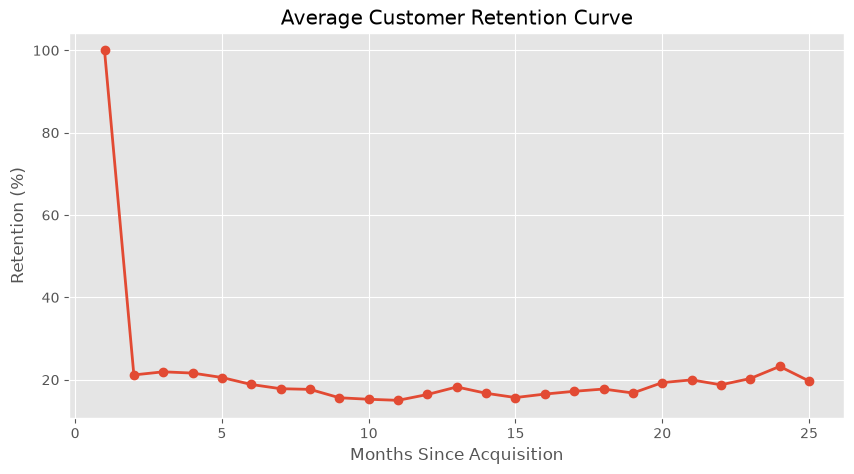

In [45]:
average_retention = retention_percentage.mean(axis=0)

plt.figure(figsize=(10, 5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o",
    linewidth=2
)

plt.title("Average Customer Retention Curve")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Retention (%)")

plt.grid(True)

plt.show()

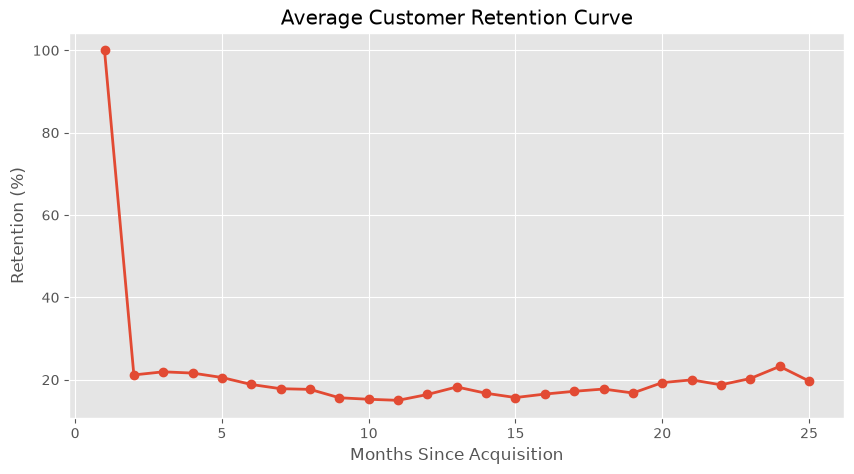

In [46]:
average_retention = retention_percentage.mean(axis=0)

plt.figure(figsize=(10, 5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o",
    linewidth=2
)

plt.title("Average Customer Retention Curve")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Retention (%)")

plt.grid(True)

plt.show()

In [47]:
for i in range(len(average_retention) - 1):
    drop = average_retention.iloc[i] - average_retention.iloc[i + 1]
    print(f"Month {i+1} → Month {i+2}: {drop:.2f}% drop")

Month 1 → Month 2: 78.83% drop
Month 2 → Month 3: -0.76% drop
Month 3 → Month 4: 0.31% drop
Month 4 → Month 5: 1.07% drop
Month 5 → Month 6: 1.70% drop
Month 6 → Month 7: 1.02% drop
Month 7 → Month 8: 0.16% drop
Month 8 → Month 9: 2.04% drop
Month 9 → Month 10: 0.37% drop
Month 10 → Month 11: 0.26% drop
Month 11 → Month 12: -1.42% drop
Month 12 → Month 13: -1.83% drop
Month 13 → Month 14: 1.53% drop
Month 14 → Month 15: 1.04% drop
Month 15 → Month 16: -0.84% drop
Month 16 → Month 17: -0.68% drop
Month 17 → Month 18: -0.55% drop
Month 18 → Month 19: 0.97% drop
Month 19 → Month 20: -2.52% drop
Month 20 → Month 21: -0.66% drop
Month 21 → Month 22: 1.20% drop
Month 22 → Month 23: -1.53% drop
Month 23 → Month 24: -2.94% drop
Month 24 → Month 25: 3.54% drop


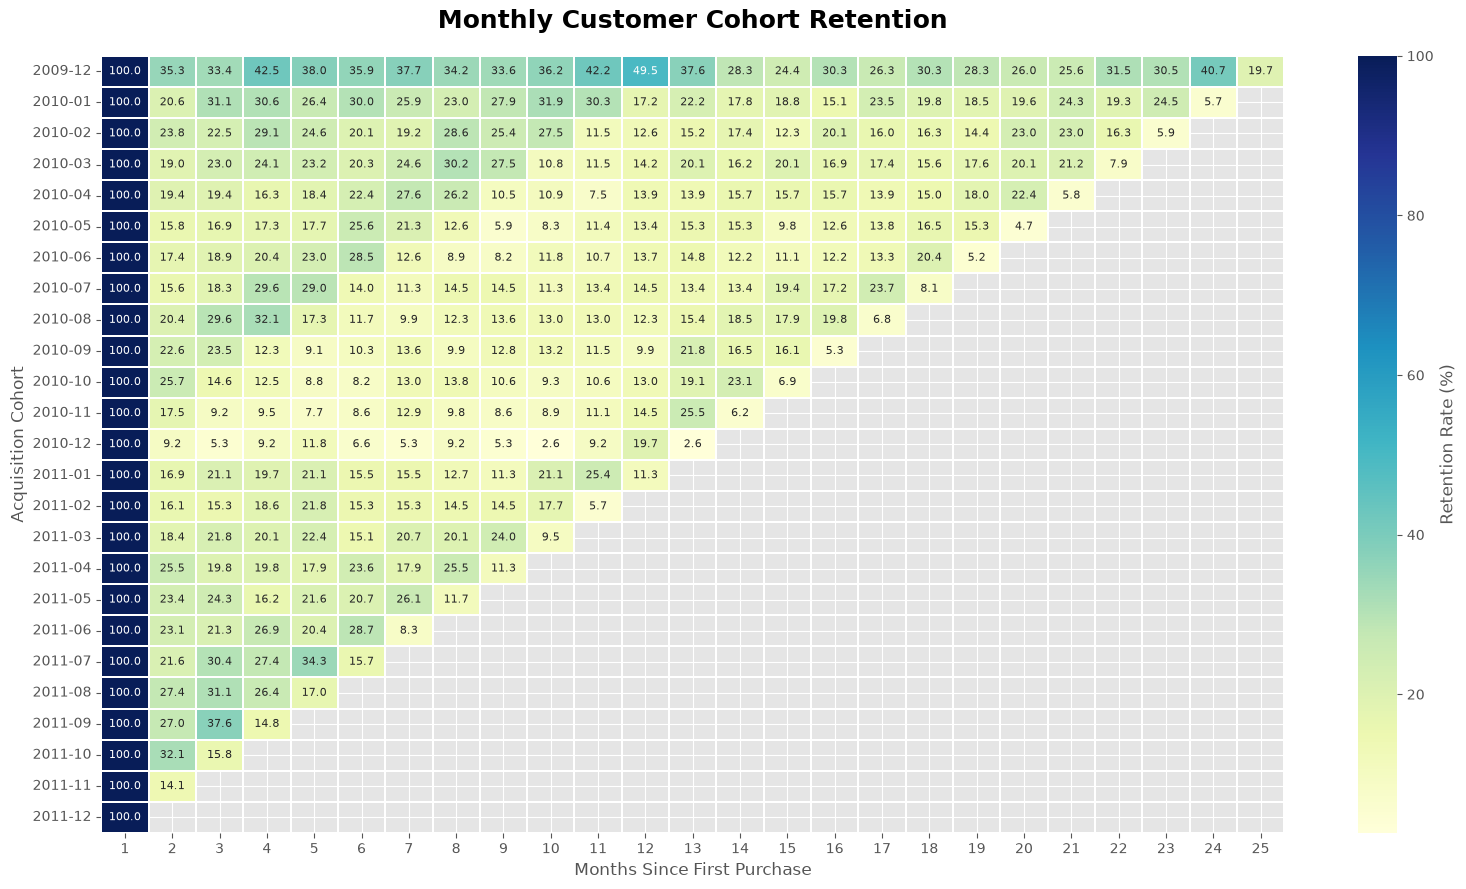

In [48]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Retention Rate (%)"},
    annot_kws={"size": 8}
)

plt.title(
    "Monthly Customer Cohort Retention",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Months Since First Purchase", fontsize=12)
plt.ylabel("Acquisition Cohort", fontsize=12)

plt.tight_layout()
plt.show()

## 📈 Business Insights

### Key Findings

- Customer retention is highest during the acquisition month (Month 1), as expected.
- Retention gradually decreases in subsequent months, indicating natural customer churn.
- Some cohorts demonstrate stronger long-term retention than others, suggesting differences in customer acquisition quality or purchasing behavior.
- The steepest decline generally occurs during the first few months after acquisition, highlighting the importance of early customer engagement.
- Customers who remain active beyond the initial months are more likely to become loyal and contribute higher lifetime value.

### Business Recommendations

- Improve customer onboarding during the first month.
- Launch personalized retention campaigns for customers at risk of churning.
- Analyze acquisition channels associated with high-retention cohorts.
- Offer loyalty rewards to encourage repeat purchases.
- Monitor cohort performance monthly to evaluate marketing effectiveness.

In [49]:
import os

os.makedirs("images", exist_ok=True)

In [ ]:
!git clone https://github.com/arjunkacha/saas-cohort-retention-cltv-analysis.git

Cloning into 'saas-cohort-retention-cltv-analysis'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 70 (delta 32), reused 43 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 15.50 MiB | 31.69 MiB/s, done.
Resolving deltas: 100% (32/32), done.


In [ ]:
%cd saas-cohort-retention-cltv-analysis

/content/saas-cohort-retention-cltv-analysis


# Week 3: Customer Lifetime Value (CLTV) Analysis

## Average Order Value (AOV)

Average Order Value represents the average revenue generated from each customer order. It is one of the key metrics used to estimate Customer Lifetime Value (CLTV).

In [50]:
customer_summary = (
    df.groupby("Customer ID")
      .agg(
          TotalOrders=("Invoice", "nunique"),
          TotalRevenue=("Revenue", "sum")
      )
      .reset_index()
)

customer_summary.head()

,Customer ID,TotalOrders,TotalRevenue
0,12346.0,12,77556.46
1,12347.0,8,4921.53
2,12348.0,5,2019.40
3,12349.0,4,4428.69
4,12350.0,1,334.40


In [51]:
customer_summary["AverageOrderValue"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["TotalOrders"]
)

customer_summary.head()

,Customer ID,TotalOrders,TotalRevenue,AverageOrderValue
0,12346.0,12,77556.46,6463.038333
1,12347.0,8,4921.53,615.191250
2,12348.0,5,2019.40,403.880000
3,12349.0,4,4428.69,1107.172500
4,12350.0,1,334.40,334.400000


In [52]:
overall_aov = customer_summary["AverageOrderValue"].mean()

print(f"Overall Average Order Value: £{overall_aov:.2f}")

Overall Average Order Value: £385.18


In [53]:
customer_summary["AverageOrderValue"].describe()

count     5878.000000
mean       385.180841
std       1214.286459
min          2.950000
25%        176.682500
50%        279.242679
75%        414.902458
max      84236.250000
Name: AverageOrderValue, dtype: float64

In [54]:
customer_summary.sort_values(
    by="AverageOrderValue",
    ascending=False
).head(10)

,Customer ID,TotalOrders,TotalRevenue,AverageOrderValue
4061,16446.0,2,168472.50,84236.250000
3371,15749.0,3,44534.30,14844.766667
2722,15098.0,3,39916.50,13305.500000
1324,13687.0,1,11880.84,11880.840000
569,12918.0,1,10953.50,10953.500000
5642,18052.0,1,10877.18,10877.180000
3382,15760.0,2,13916.34,6958.170000
1538,13902.0,5,34095.26,6819.052000
0,12346.0,12,77556.46,6463.038333
11,12357.0,3,18287.66,6095.886667


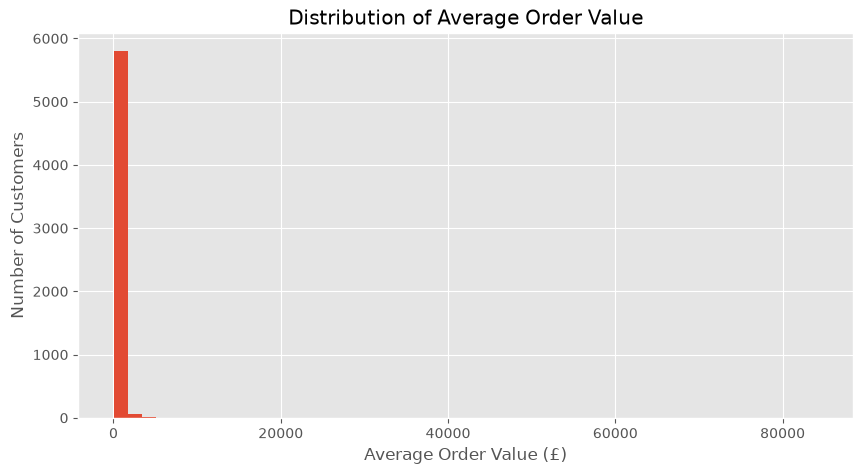

In [55]:
plt.figure(figsize=(10,5))

plt.hist(customer_summary["AverageOrderValue"], bins=50)

plt.title("Distribution of Average Order Value")
plt.xlabel("Average Order Value (£)")
plt.ylabel("Number of Customers")

plt.show()

## 📈 Business Insight

### Key Findings

- Average Order Value (AOV) measures the average revenue generated per customer order.
- Customers with higher AOV contribute significantly more revenue per transaction.
- Identifying high-value customers enables businesses to design targeted loyalty programs and premium marketing campaigns.
- AOV serves as a foundational metric for calculating Customer Lifetime Value (CLTV).

## 3.2 Purchase Frequency

Purchase Frequency measures the average number of orders placed by each customer. It helps businesses understand customer buying behavior and plays a significant role in Customer Lifetime Value (CLTV) estimation.

In [56]:
total_orders = customer_summary["TotalOrders"].sum()

total_customers = customer_summary["Customer ID"].nunique()

purchase_frequency = total_orders / total_customers

print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Purchase Frequency: {purchase_frequency:.2f}")

Total Orders: 36969
Total Customers: 5878
Purchase Frequency: 6.29


In [57]:
customer_summary["TotalOrders"].describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: TotalOrders, dtype: float64

In [58]:
top_repeat_customers = (
    customer_summary
    .sort_values(by="TotalOrders", ascending=False)
    .head(10)
)

top_repeat_customers

,Customer ID,TotalOrders,TotalRevenue,AverageOrderValue
2538,14911.0,398,291420.81,732.213090
400,12748.0,336,53539.64,159.344167
5433,17841.0,211,68545.25,324.859005
2935,15311.0,208,114966.42,552.723173
739,13089.0,203,113416.91,558.703990
2237,14606.0,192,29951.37,155.996719
1789,14156.0,156,313437.62,2009.215513
5442,17850.0,155,51208.87,330.379806
2277,14646.0,151,528602.52,3500.678940
5692,18102.0,145,580987.04,4006.807172


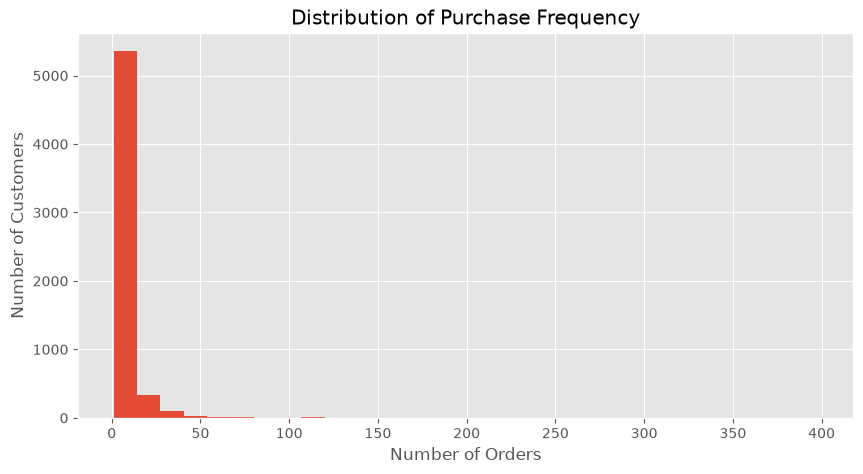

In [59]:
plt.figure(figsize=(10,5))

plt.hist(customer_summary["TotalOrders"], bins=30)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

## 📈 Business Insight

### Key Findings

- Purchase Frequency indicates how often customers return to make additional purchases.
- Customers with higher purchase frequency generally have greater long-term value.
- A small percentage of customers typically generate a large proportion of repeat orders.
- Increasing repeat purchases through loyalty programs and personalized offers can significantly improve Customer Lifetime Value (CLTV).

### Business Recommendations

- Reward repeat customers with loyalty benefits.
- Use personalized email campaigns to encourage second and third purchases.
- Identify low-frequency customers and design re-engagement campaigns.
- Monitor purchase frequency over time to evaluate retention strategies.

In [60]:
customer_summary["PurchaseCategory"] = pd.cut(
    customer_summary["TotalOrders"],
    bins=[0, 1, 5, 10, customer_summary["TotalOrders"].max()],
    labels=["One-Time", "Occasional", "Frequent", "Loyal"]
)

customer_summary["PurchaseCategory"].value_counts()

PurchaseCategory
Occasional    2454
One-Time      1623
Frequent       925
Loyal          876
Name: count, dtype: int64

## 3.3 Customer Lifespan

Customer Lifespan represents the duration for which a customer remains active. It is calculated as the time between the customer's first and last purchase and is an important factor in estimating Customer Lifetime Value (CLTV).

In [61]:
customer_lifespan = (
    df.groupby("Customer ID")["InvoiceDate"]
      .agg(["min", "max"])
      .reset_index()
)

customer_lifespan["CustomerLifespanDays"] = (
    customer_lifespan["max"] -
    customer_lifespan["min"]
).dt.days

customer_lifespan.head()

,Customer ID,min,max,CustomerLifespanDays
0,12346.0,2009-12-14 08:34:00,2011-01-18 10:01:00,400
1,12347.0,2010-10-31 14:20:00,2011-12-07 15:52:00,402
2,12348.0,2010-09-27 14:59:00,2011-09-25 13:13:00,362
3,12349.0,2010-04-29 13:20:00,2011-11-21 09:51:00,570
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,0


In [62]:
customer_summary = customer_summary.merge(
    customer_lifespan[
        ["Customer ID", "CustomerLifespanDays"]
    ],
    on="Customer ID",
    how="left"
)

customer_summary.head()

,Customer ID,TotalOrders,TotalRevenue,AverageOrderValue,PurchaseCategory,CustomerLifespanDays
0,12346.0,12,77556.46,6463.038333,Loyal,400
1,12347.0,8,4921.53,615.191250,Frequent,402
2,12348.0,5,2019.40,403.880000,Occasional,362
3,12349.0,4,4428.69,1107.172500,Occasional,570
4,12350.0,1,334.40,334.400000,One-Time,0


In [63]:
average_lifespan = customer_summary[
    "CustomerLifespanDays"
].mean()

print(f"Average Customer Lifespan: {average_lifespan:.2f} days")

Average Customer Lifespan: 273.02 days


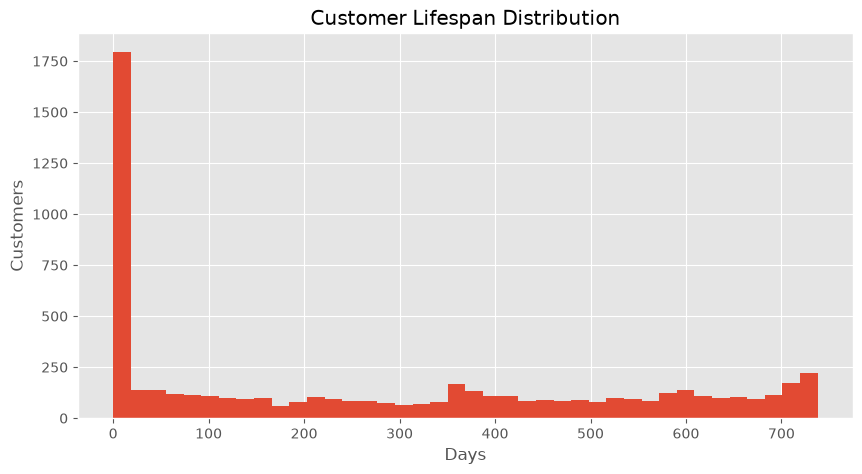

In [64]:
plt.figure(figsize=(10,5))

plt.hist(
    customer_summary["CustomerLifespanDays"],
    bins=40
)

plt.title("Customer Lifespan Distribution")
plt.xlabel("Days")
plt.ylabel("Customers")

plt.show()

### 📈 Business Insight

- Customers with longer lifespans generally generate more revenue.
- Increasing customer retention directly improves Customer Lifetime Value.
- Businesses should focus on extending customer relationships through loyalty programs and personalized engagement.

## 3.4 Historical Customer Lifetime Value (CLTV)

Historical CLTV estimates the total revenue generated by a customer over their observed lifetime using historical transaction data.

In [65]:
customer_summary["CustomerLifespanYears"] = (
    customer_summary["CustomerLifespanDays"] / 365
)

customer_summary["HistoricalCLTV"] = (
    customer_summary["AverageOrderValue"]
    * customer_summary["TotalOrders"]
    * customer_summary["CustomerLifespanYears"]
)

customer_summary.head()

,Customer ID,TotalOrders,TotalRevenue,AverageOrderValue,PurchaseCategory,CustomerLifespanDays,CustomerLifespanYears,HistoricalCLTV
0,12346.0,12,77556.46,6463.038333,Loyal,400,1.095890,84993.380822
1,12347.0,8,4921.53,615.191250,Frequent,402,1.101370,5420.424822
2,12348.0,5,2019.40,403.880000,Occasional,362,0.991781,2002.802192
3,12349.0,4,4428.69,1107.172500,Occasional,570,1.561644,6916.036438
4,12350.0,1,334.40,334.400000,One-Time,0,0.000000,0.000000


In [66]:
customer_summary["HistoricalCLTV"].describe()

count    5.878000e+03
mean     4.388546e+03
std      2.775327e+04
min      0.000000e+00
25%      0.000000e+00
50%      4.858848e+02
75%      2.618783e+03
max      1.174708e+06
Name: HistoricalCLTV, dtype: float64

In [67]:
customer_summary.sort_values(
    by="HistoricalCLTV",
    ascending=False
).head(10)

,Customer ID,TotalOrders,TotalRevenue,AverageOrderValue,PurchaseCategory,CustomerLifespanDays,CustomerLifespanYears,HistoricalCLTV
5692,18102.0,145,580987.04,4006.807172,Loyal,738,2.021918,1.174708e+06
2277,14646.0,151,528602.52,3500.678940,Loyal,735,2.013699,1.064446e+06
1789,14156.0,156,313437.62,2009.215513,Loyal,728,1.994521,6.251578e+05
2538,14911.0,398,291420.81,732.213090,Loyal,737,2.019178,5.884305e+05
1331,13694.0,143,195640.69,1368.116713,Loyal,731,2.002740,3.918174e+05
5109,17511.0,60,172132.87,2868.881167,Loyal,734,2.010959,3.461521e+05
4295,16684.0,55,147142.77,2675.323091,Loyal,728,1.994521,2.934793e+05
5050,17450.0,51,244784.25,4799.691176,Loyal,429,1.175342,2.877053e+05
2685,15061.0,127,126389.02,995.189134,Loyal,734,2.010959,2.541631e+05
5540,17949.0,118,117314.08,994.187119,Loyal,736,2.016438,2.365566e+05


In [68]:
customer_summary["HistoricalCLTV"].describe()

count    5.878000e+03
mean     4.388546e+03
std      2.775327e+04
min      0.000000e+00
25%      0.000000e+00
50%      4.858848e+02
75%      2.618783e+03
max      1.174708e+06
Name: HistoricalCLTV, dtype: float64

In [69]:
(customer_summary["HistoricalCLTV"] == 0).sum()

np.int64(1697)

In [70]:
customer_summary["CustomerSegment"] = pd.cut(
    customer_summary["HistoricalCLTV"],
    bins=[-1, 0, 500, 2500, customer_summary["HistoricalCLTV"].max()],
    labels=[
        "Inactive / Very Low",
        "Low Value",
        "High Value",
        "Premium"
    ]
)

customer_summary["CustomerSegment"].value_counts()

CustomerSegment
Inactive / Very Low    1697
Premium                1516
High Value             1390
Low Value              1275
Name: count, dtype: int64

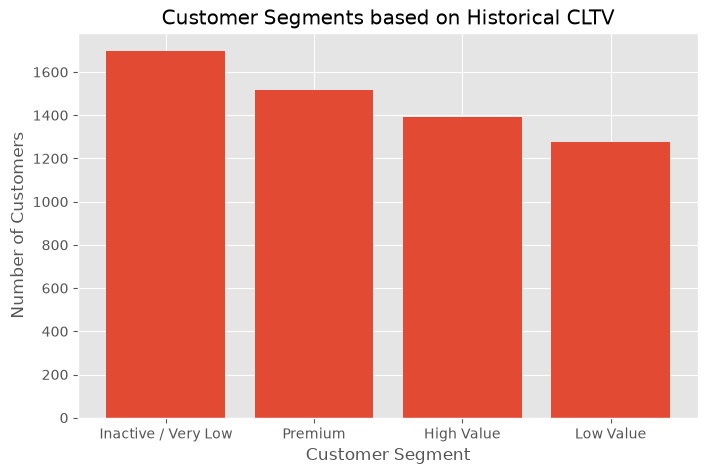

In [71]:
segment_counts = customer_summary["CustomerSegment"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(segment_counts.index.astype(str), segment_counts.values)

plt.title("Customer Segments based on Historical CLTV")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

### 📈 Business Insight

- Approximately one-third of customers fall into the **Inactive / Very Low** segment, indicating limited long-term value.
- The **Premium** segment consists of customers who contribute disproportionately to overall revenue.
- High-value customers should be prioritized through personalized marketing campaigns, loyalty programs, and premium services.
- Lower-value customers represent an opportunity for targeted retention and cross-selling strategies to increase their lifetime value.

## 3.5 Customer Lifetime Value Visualizations

Visualizing the distribution of Customer Lifetime Value (CLTV) helps identify customer spending patterns, detect outliers, and understand the proportion of high-value customers.

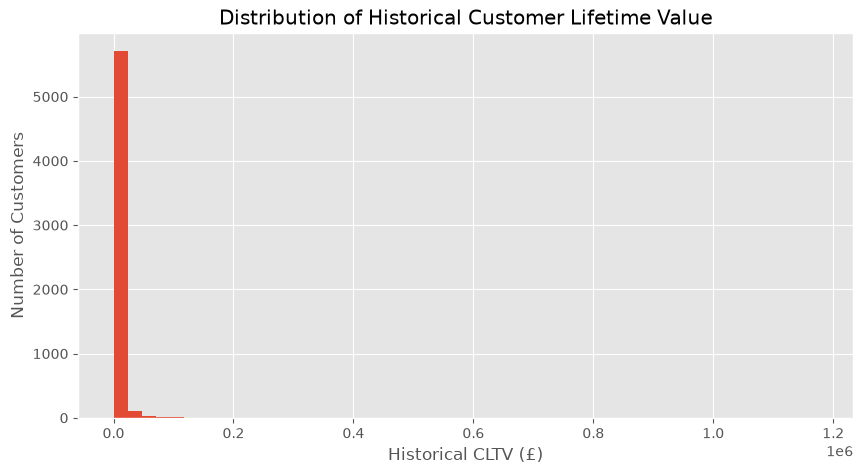

In [72]:
plt.figure(figsize=(10,5))

plt.hist(customer_summary["HistoricalCLTV"], bins=50)

plt.title("Distribution of Historical Customer Lifetime Value")
plt.xlabel("Historical CLTV (£)")
plt.ylabel("Number of Customers")

plt.show()

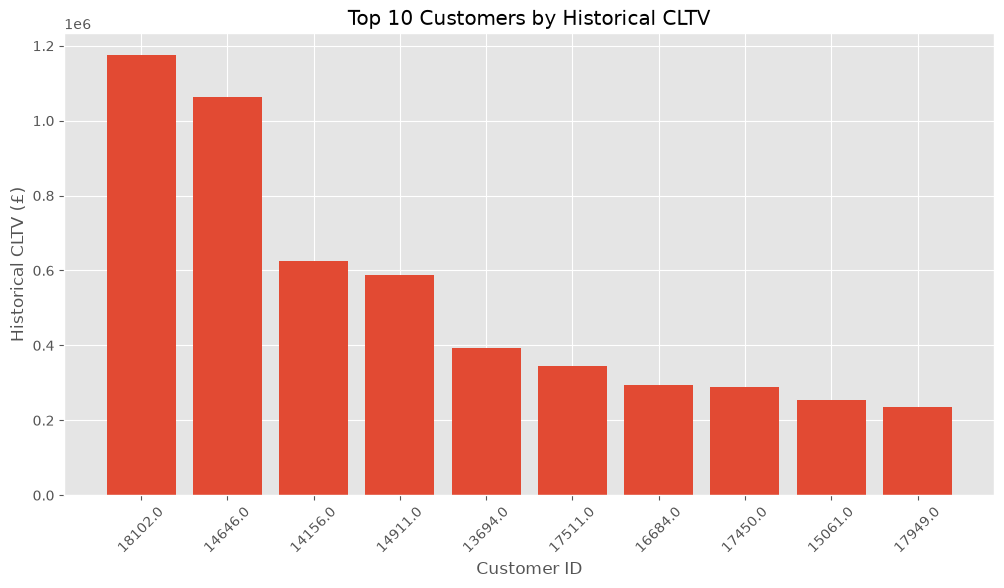

In [73]:
top_customers = (
    customer_summary
    .sort_values("HistoricalCLTV", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_customers["Customer ID"].astype(str),
    top_customers["HistoricalCLTV"]
)

plt.title("Top 10 Customers by Historical CLTV")
plt.xlabel("Customer ID")
plt.ylabel("Historical CLTV (£)")
plt.xticks(rotation=45)

plt.show()

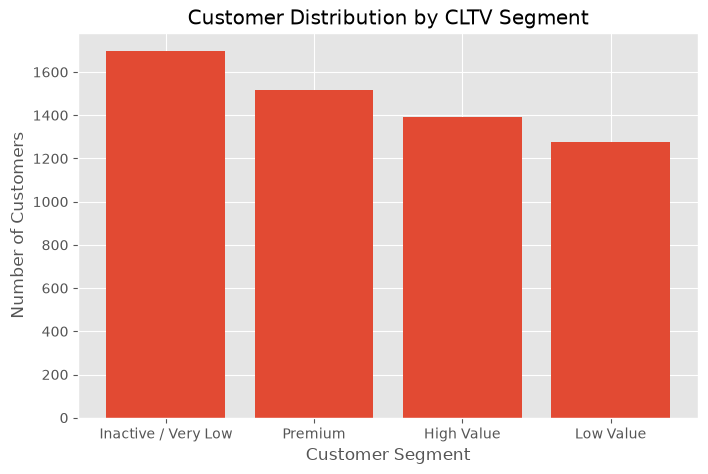

In [74]:
segment_counts = customer_summary["CustomerSegment"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    segment_counts.index.astype(str),
    segment_counts.values
)

plt.title("Customer Distribution by CLTV Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

### 📈 Business Insight

- Historical CLTV is highly skewed, with a small proportion of customers contributing significantly more revenue than the rest.
- Premium customers represent the highest-value customer segment and should receive personalized retention strategies.
- The majority of customers fall into lower-value segments, highlighting opportunities to increase repeat purchases and improve customer engagement.

# 📌 Week 3 Summary

## Key Achievements

- Calculated Average Order Value (AOV).
- Measured Purchase Frequency.
- Estimated Customer Lifespan.
- Calculated Historical Customer Lifetime Value (CLTV).
- Segmented customers based on CLTV.
- Visualized customer lifetime value and customer segments.

---

## Business Insights

- Premium customers contribute a significant portion of overall revenue despite representing a smaller customer base.
- Customers with higher purchase frequency generally have higher lifetime value.
- Extending customer lifespan through retention initiatives can significantly increase CLTV.
- Customer segmentation enables personalized marketing strategies and more efficient allocation of business resources.

---

## Business Recommendations

- Develop loyalty programs targeting Premium and High Value customers.
- Re-engage Low Value customers through personalized offers and email campaigns.
- Improve customer onboarding to encourage repeat purchases.
- Continuously monitor CLTV and retention metrics to evaluate marketing effectiveness.

---

## Conclusion

Week 3 successfully established a Customer Lifetime Value (CLTV) framework by combining Average Order Value, Purchase Frequency, Customer Lifespan, and Historical CLTV calculations. These insights provide a strong foundation for business decision-making and will be further enhanced through an interactive Power BI dashboard in Week 4.

# Week 4: Visualization & Strategic Insights

## Customer Lifetime Value Distribution

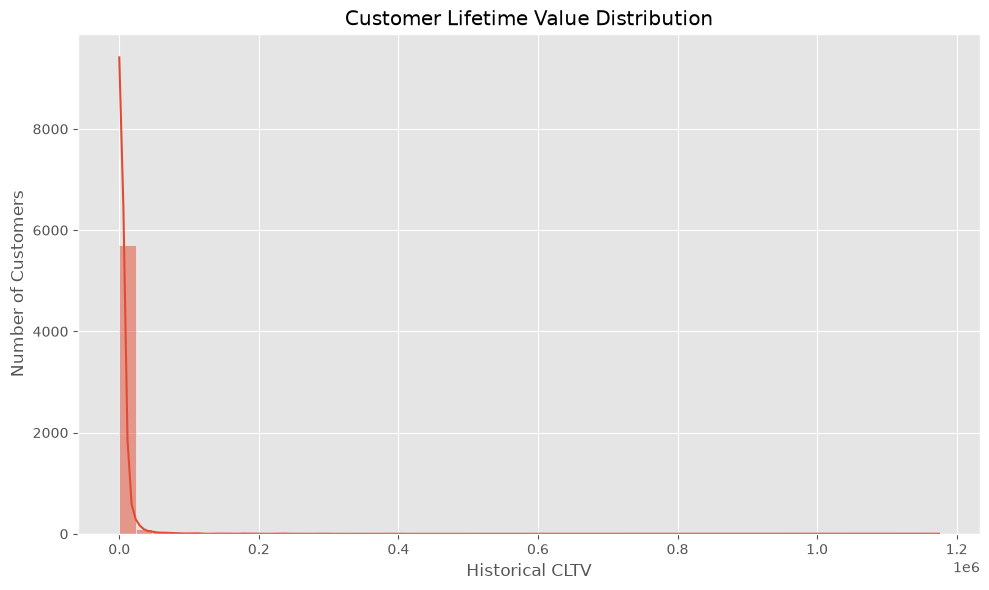

In [75]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_summary["HistoricalCLTV"],
    bins=50,
    kde=True
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Historical CLTV")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "cltv_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

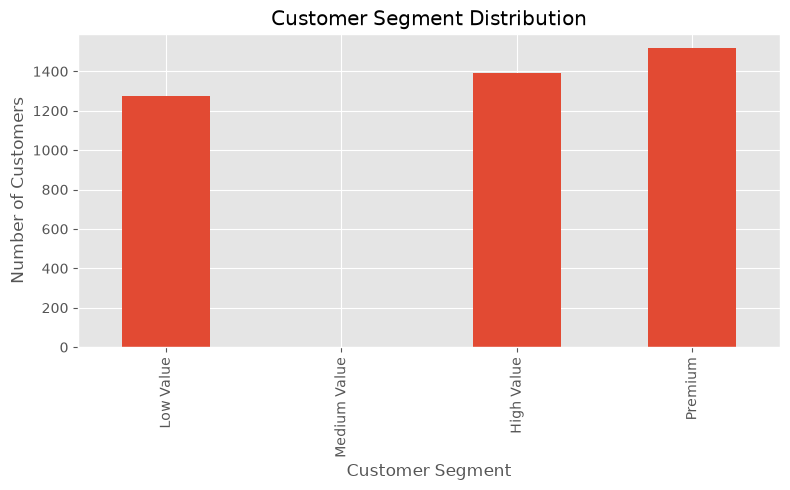

In [76]:
plt.figure(figsize=(8, 5))

customer_summary["CustomerSegment"].value_counts().reindex(
    ["Low Value", "Medium Value", "High Value", "Premium"]
).plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
top_customers = (
    customer_summary
    .sort_values("HistoricalCLTV", ascending=False)
    .head(10)
)

top_customers

,Customer ID,TotalOrders,TotalRevenue,AverageOrderValue,PurchaseCategory,CustomerLifespanDays,CustomerLifespanYears,HistoricalCLTV,CustomerSegment
5692,18102.0,145,580987.04,4006.807172,Loyal,738,2.021918,1.174708e+06,Premium
2277,14646.0,151,528602.52,3500.678940,Loyal,735,2.013699,1.064446e+06,Premium
1789,14156.0,156,313437.62,2009.215513,Loyal,728,1.994521,6.251578e+05,Premium
2538,14911.0,398,291420.81,732.213090,Loyal,737,2.019178,5.884305e+05,Premium
1331,13694.0,143,195640.69,1368.116713,Loyal,731,2.002740,3.918174e+05,Premium
5109,17511.0,60,172132.87,2868.881167,Loyal,734,2.010959,3.461521e+05,Premium
4295,16684.0,55,147142.77,2675.323091,Loyal,728,1.994521,2.934793e+05,Premium
5050,17450.0,51,244784.25,4799.691176,Loyal,429,1.175342,2.877053e+05,Premium
2685,15061.0,127,126389.02,995.189134,Loyal,734,2.010959,2.541631e+05,Premium
5540,17949.0,118,117314.08,994.187119,Loyal,736,2.016438,2.365566e+05,Premium


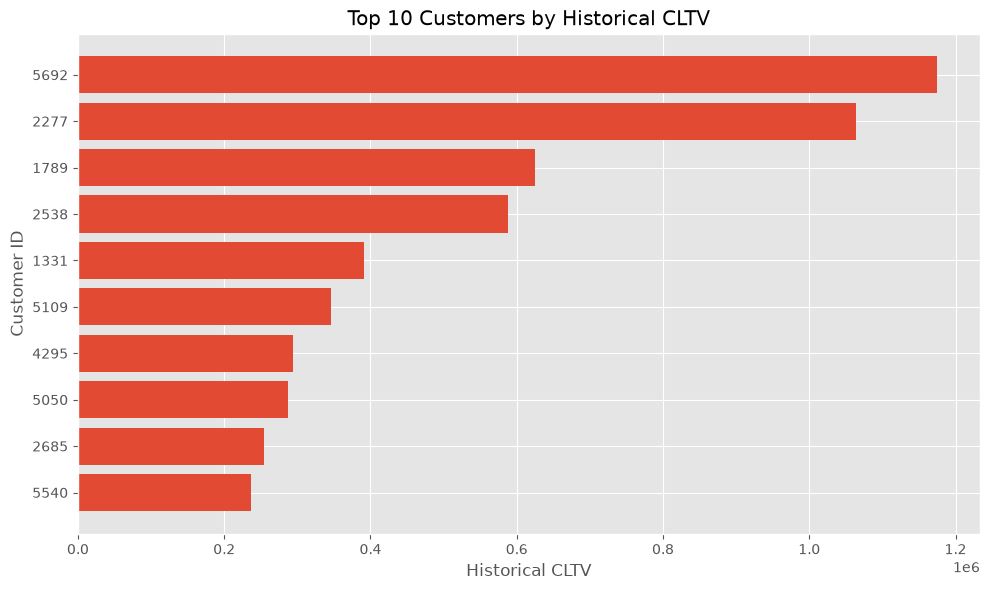

In [78]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers.index.astype(str),
    top_customers["HistoricalCLTV"]
)

plt.title("Top 10 Customers by Historical CLTV")
plt.xlabel("Historical CLTV")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "top_10_customers_cltv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
segment_summary = (
    customer_summary
    .groupby("CustomerSegment")
    .agg(
        Customers=("HistoricalCLTV", "count"),
        AverageCLTV=("HistoricalCLTV", "mean"),
        TotalCLTV=("HistoricalCLTV", "sum")
    )
    .reindex(
        ["Low Value", "Medium Value", "High Value", "Premium"]
    )
)

segment_summary

,Customers,AverageCLTV,TotalCLTV
CustomerSegment,,,
Low Value,1275.0,202.326910,2.579668e+05
Medium Value,NaN,NaN,NaN
High Value,1390.0,1255.712332,1.745440e+06
Premium,1516.0,15694.240791,2.379247e+07


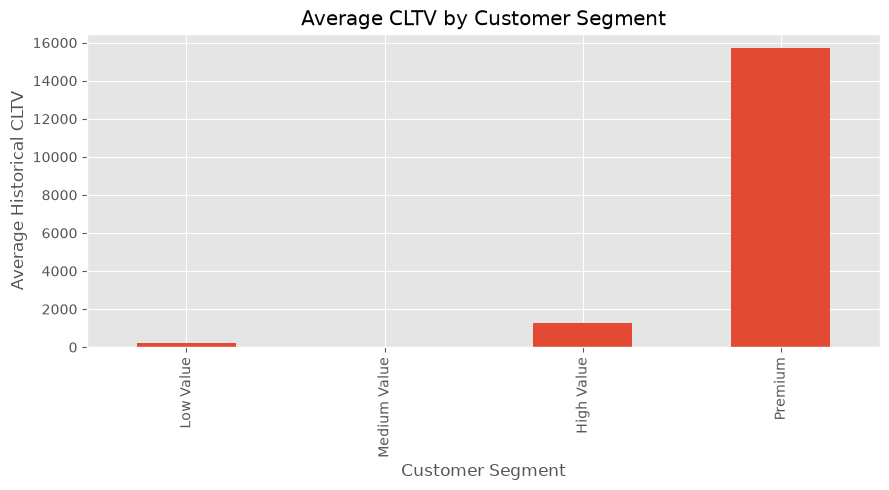

In [80]:
plt.figure(figsize=(9, 5))

segment_summary["AverageCLTV"].plot(kind="bar")

plt.title("Average CLTV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Historical CLTV")

plt.tight_layout()

plt.savefig(
    "average_cltv_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [88]:
from pathlib import Path
import shutil

# Project root
PROJECT_ROOT = Path.cwd().parent

# The generated PNG files are directly inside notebooks/
SOURCE_DIR = PROJECT_ROOT / "notebooks"

# Final repository images folder
DEST_DIR = PROJECT_ROOT / "images"

# Make sure images folder exists
DEST_DIR.mkdir(exist_ok=True)

files = [
    "average_cltv_by_segment.png",
    "cltv_distribution.png",
    "customer_segment_distribution.png",
    "top_10_customers_cltv.png"
]

for file in files:
    source = SOURCE_DIR / file
    destination = DEST_DIR / file

    if source.exists():
        shutil.copy2(source, destination)
        print(f"Copied: {file}")
    else:
        print(f"NOT FOUND: {source}")

Copied: average_cltv_by_segment.png
Copied: cltv_distribution.png
Copied: customer_segment_distribution.png
Copied: top_10_customers_cltv.png


## 📊 Power BI Data Preparation

The following customer-level dataset contains the metrics required for the Power BI CLTV and customer segmentation dashboard.

In [89]:
# Prepare customer-level dataset for Power BI

powerbi_customer = customer_summary[
    [
        "Customer ID",
        "TotalOrders",
        "TotalRevenue",
        "AverageOrderValue",
        "CustomerLifespanDays",
        "CustomerLifespanYears",
        "HistoricalCLTV",
        "CustomerSegment"
    ]
].copy()

powerbi_customer.head()

,Customer ID,TotalOrders,TotalRevenue,AverageOrderValue,CustomerLifespanDays,CustomerLifespanYears,HistoricalCLTV,CustomerSegment
0,12346.0,12,77556.46,6463.038333,400,1.095890,84993.380822,Premium
1,12347.0,8,4921.53,615.191250,402,1.101370,5420.424822,Premium
2,12348.0,5,2019.40,403.880000,362,0.991781,2002.802192,High Value
3,12349.0,4,4428.69,1107.172500,570,1.561644,6916.036438,Premium
4,12350.0,1,334.40,334.400000,0,0.000000,0.000000,Inactive / Very Low


In [90]:
# Export customer-level CLTV dataset

powerbi_customer.to_csv(
    "customer_cltv_summary.csv",
    index=False
)

print("Customer CLTV dataset created successfully.")
print(f"Rows: {len(powerbi_customer):,}")
print(f"Columns: {len(powerbi_customer.columns)}")

Customer CLTV dataset created successfully.
Rows: 5,878
Columns: 8


In [91]:
# Prepare cohort retention data for Power BI

powerbi_retention = (
    retention_percentage
    .reset_index()
    .melt(
        id_vars="CohortMonth",
        var_name="CohortIndex",
        value_name="RetentionRate"
    )
)

powerbi_retention.to_csv(
    "cohort_retention_powerbi.csv",
    index=False
)

print("Cohort retention dataset created successfully.")
print(f"Rows: {len(powerbi_retention):,}")

display(powerbi_retention.head())

Cohort retention dataset created successfully.
Rows: 625


,CohortMonth,CohortIndex,RetentionRate
0,2009-12,1,100.0
1,2010-01,1,100.0
2,2010-02,1,100.0
3,2010-03,1,100.0
4,2010-04,1,100.0
